# Grid Network Analysis - Part B, Task 4-5: Merging/Advanced Analysis and Visualization

**Scope**: this notebook covers Part B's Task 4 (Merging and Advanced
Analysis) and Task 5 (Visualization and Network Analysis) - the
tutorial-style walkthrough tasks, distinct from Part A's week-numbered
tasks already covered elsewhere in this folder.

**What's genuinely new here** versus what already exists:
- Task 4's actual 3-table merge is `merge_all()` in `../src/cleaning.py`,
  already built and used in `01_data_cleaning_and_eda.ipynb`. The new piece
  in this notebook is the **utility/region line-count breakdown** it asks
  for on top of that merge.
- Task 5's NetworkX graph, centrality, and N-1 contingency test already
  exist in full in `../src/network.py` (Part A Task 2.1) and are narrated
  in depth in `02_network_analysis.ipynb` - this notebook just reuses those
  same functions for a quick top-10 summary, rather than rebuilding them.
  The genuinely new piece is the **Plotly interactive map**
  (`px.scatter_geo`), which is a different tool from the Folium map already
  built for Task 2.2 (`03_geographic_analysis.ipynb`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))
from src.cleaning import load_raw, clean_and_validate, merge_all, utility_region_line_counts
from src.network import build_graph, compute_centrality, n1_contingency
from src.geo import build_plotly_substation_map

DATA_DIR = Path("../data")
OUTPUTS_DIR = Path("../outputs")
CHARTS_DIR = OUTPUTS_DIR / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

utilities, substations, lines = load_raw(DATA_DIR)
utilities, substations, lines, _ = clean_and_validate(utilities, substations, lines)
merged = merge_all(utilities, substations, lines)
merged.head()

,Line ID,Utility ID,Source Substation ID,Source Substation,Destination Substation ID,Destination Substation,Voltage (kV),Length (km),Capacity (MVA),Status,Line Type,Source Name,Source Region,Source Country,Destination Name,Destination Region,Destination Country,Utility Name,Utility Alias,Utility Code
0,1,2,1,Achimota Substation,2,Tema Substation,11,25.2,215.0,Active,Underground,Achimota Substation,Greater Accra,Ghana,Tema Substation,Greater Accra,Ghana,Northern Electricity Distribution Company,NEDCo,NED
1,2,2,1,Achimota Substation,3,Mallam Substation,11,11.0,36.4,Active,Overhead,Achimota Substation,Greater Accra,Ghana,Mallam Substation,Greater Accra,Ghana,Northern Electricity Distribution Company,NEDCo,NED
2,3,3,1,Achimota Substation,5,Kaneshie Substation,11,5.9,277.4,Active,Overhead,Achimota Substation,Greater Accra,Ghana,Kaneshie Substation,Greater Accra,Ghana,Ghana Grid Company,GRIDCo,GRD
3,4,1,2,Tema Substation,3,Mallam Substation,330,34.4,39.0,Active,Underground,Tema Substation,Greater Accra,Ghana,Mallam Substation,Greater Accra,Ghana,Electricity Company of Ghana,ECG,ECG
4,5,3,2,Tema Substation,4,Legon Substation,161,19.5,186.5,Active,Underground,Tema Substation,Greater Accra,Ghana,Legon Substation,Greater Accra,Ghana,Ghana Grid Company,GRIDCo,GRD


## Task 4: Merging and Advanced Analysis

The merge above already joins every line with both substations' details
and the operating utility's details (see `../src/cleaning.py`'s
`merge_all()`, first built for Task 1.3). Task 4 asks specifically: which
utility operates the most lines, broken down by source region?

In [2]:
utility_region_counts = utility_region_line_counts(merged)
print("Top 10 Utility/Region Combinations by Line Count:")
utility_region_counts.head(10)

Top 10 Utility/Region Combinations by Line Count:


,Utility Code,Source Region,Line Count
0,GRD,Greater Accra,5
1,NED,Greater Accra,4
2,NED,Central,3
3,NED,Ashanti,3
4,GRD,Western,3
5,GRD,Volta,3
6,GRD,Eastern,3
7,GRD,Bono,3
8,ECG,Western,2
9,GRD,Ashanti,2


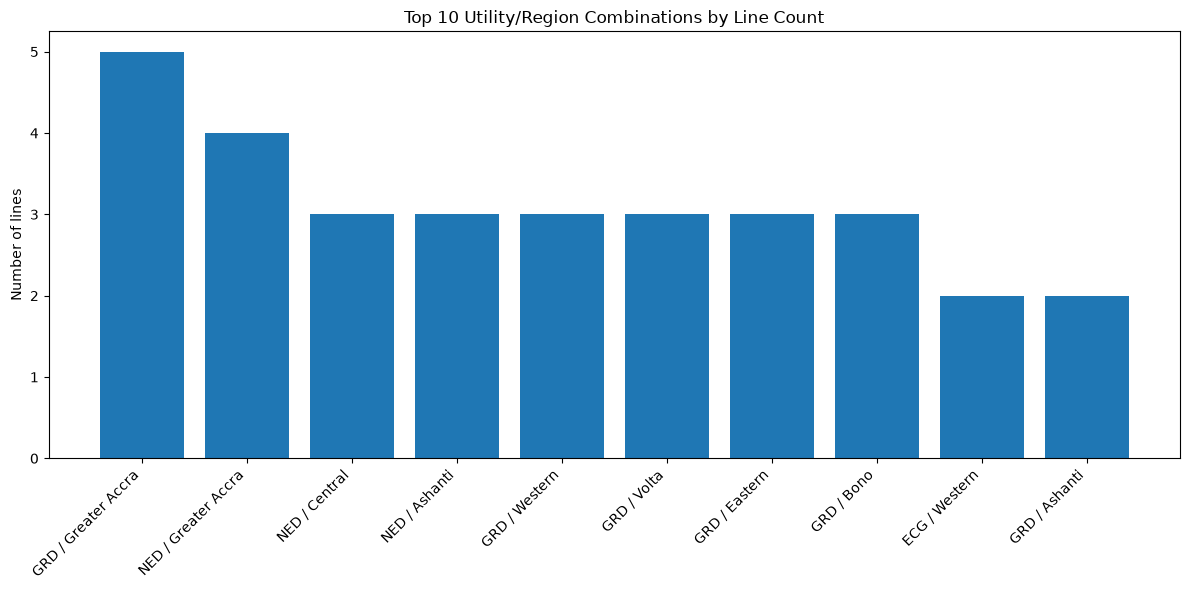

In [3]:
top10 = utility_region_counts.head(10)
plt.figure(figsize=(12, 6))
plt.bar(top10["Utility Code"] + " / " + top10["Source Region"], top10["Line Count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of lines")
plt.title("Top 10 Utility/Region Combinations by Line Count")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "utility_region_line_counts.png")
plt.show()

## Task 5: Visualization and Network Analysis

### Interactive map (Plotly `scatter_geo`)

A lighter-weight, quick-look alternative to the fuller Folium map built for
Task 2.2 - useful for fast exploration directly inside a notebook cell.

In [4]:
fig = build_plotly_substation_map(substations, color_by="Region")
fig.write_html(str(OUTPUTS_DIR / "substation_map_plotly.html"))
fig.show()

### Network analysis (reusing Task 2.1's functions)

The full network build-out, all five centrality measures, community
detection, bridges, and the N-1 discussion live in
`02_network_analysis.ipynb`. This section just reuses those same
`../src/network.py` functions for the specific quick-look Task 5 asks for:
top-10 substations by degree centrality, and one N-1 contingency check.

In [5]:
G = build_graph(substations, lines)
print(f"Nodes (substations): {G.number_of_nodes()}")
print(f"Edges (lines): {G.number_of_edges()}")

centrality = compute_centrality(G)
print("\nTop 10 substations by degree centrality:")
centrality[["name", "region", "degree_centrality"]].head(10)

Nodes (substations): 44
Edges (lines): 55

Top 10 substations by degree centrality:


,name,region,degree_centrality
substation_id,,,
16,Cape Coast Substation,Central,0.116279
3,Mallam Substation,Greater Accra,0.116279
7,Kumasi Central Substation,Ashanti,0.116279
1,Achimota Substation,Greater Accra,0.093023
4,Legon Substation,Greater Accra,0.093023
24,Ho Substation,Volta,0.093023
2,Tema Substation,Greater Accra,0.093023
20,Koforidua Substation,Eastern,0.093023
11,Konongo Substation,Ashanti,0.093023


In [6]:
top_hub_id = centrality["degree_centrality"].idxmax()
n1_contingency(G, node_id=top_hub_id)

{'removed_node': np.int64(16),
 'removed_node_name': 'Cape Coast Substation',
 'components_before': 3,
 'components_after': 5,
 'component_sizes_before': [42, 1, 1],
 'component_sizes_after': [20, 18, 3, 1, 1],
 'network_fragmented': True}

## Summary

- The utility/region breakdown confirms the pattern already seen in Week
  1's EDA (GRIDCo operating the most lines overall) but sharpens it to
  *which* regions specifically drive that count.
- The Plotly map is a quick complementary view to the fuller Folium map in
  `03_geographic_analysis.ipynb` - same underlying substation data, a
  different (simpler, less interactive) rendering.
- The centrality/N-1 results here are identical to `02_network_analysis.ipynb`,
  since both call the exact same `../src/network.py` functions on the same
  data - reused, not recomputed differently.

## Notes and limitations

All figures above are derived from the same **synthetic**, seeded dataset
used throughout this project - see
`../../docs/architecture-diagrams/grid-analysis-data-dictionary.md` for its
description and limitations.